# Process Notebook

## Abstract

This project investigates sentiment classification across multiple social-media platforms, examining how label quality, feature representation, and modeling strategies influence performance when predicting positive, negative, and neutral sentiment. Using a large, heterogeneous dataset, we compared traditional machine-learning methods—primarily TF–IDF + Logistic Regression—with transformer-based models such as DistilBERT, while also evaluating the value of metadata including sarcasm indicators and community information. The most decisive finding was that label clarity, not model complexity, drove performance: cleaning ambiguous neutral labels produced the largest gains across accuracy, macro-F1, precision, and recall. A two-stage classification pipeline that first distinguishes neutral from non-neutral posts and then separates positive from negative sentiment outperformed all single-stage classical models and achieved the highest MCC among TF–IDF approaches, effectively capturing the benefits of label cleaning without discarding data. Exploratory analyses of temporal trends and topic-specific sentiment revealed fluctuating, non-directional patterns and no consistent negativity associated with specific identity groups or controversial topics. Overall, the results highlight that strategic data preprocessing and task structure can allow simple models to rival transformers, and that sentiment dynamics across platforms are more cyclical and context-dependent than uniformly polarized.

## Overview and Motivation: 

This project examines how effectively sentiment can be classified across diverse social-media platforms by analyzing the roles of label quality, feature representation, and model design. Working with a large, multi-community dataset, the study contrasts traditional text-based approaches (TF–IDF + Logistic Regression) with transformer models like DistilBERT, and evaluates whether supplemental metadata, such as sarcasm markers or community identifiers. contributes meaningful improvements. One of the central outcomes is that a two-stage modeling strategy, which first filters posts into neutral versus non-neutral categories before distinguishing positive from negative sentiment, consistently surpasses single-stage three-class classifiers on metrics including accuracy, macro-F1, precision, and recall.

The broader motivation stems from growing interest in how online communication shapes public discourse and whether emotional tone varies across platforms, topics, and groups. Tools like VADER make it possible to quantify sentiment at scale, offering a foundation for investigating how different communities express affect, how contentious subjects may influence tone, and whether platform-specific norms contribute to shifts in sentiment patterns.

The project’s objectives include:

    (1) Conduct exploratory analyses of sentiment trends across time, platforms, and topics.
    (2) Identify whether certain identity groups or controversial topics consistently elicit shifts toward negative sentiment.
    (3) Build baseline sentiment classifiers using text-only features.
    (4) Incorporate metadata (e.g., sarcasm indicators, community information) to evaluate whether context improves a classifier's performance.


## Related Work

This project was inspired by broader research on online polarization and the emotional dynamics of digital communities. Prior studies have shown that social-media platforms can amplify conflict, encourage echo chambers, and shape how people express sentiment in public discourse. Discussions in class about affective computing and linguistic signaling also informed this work, motivating an exploration of how sentiment can be classified as it shifts across platforms and topics. 

One article, “Exposure to opposing views on social media can increase political polarization” (Bail et al., 2018), particularly influenced this project by demonstrating that interactions on social-media platforms can intensify affective polarization rather than reduce it. The study shows that exposure to politically opposing content often heightens negative emotional responses and strengthens in-group identity, underscoring how digital environments shape sentiment expression and contribute to polarized public discourse.

source: https://www.pnas.org/doi/10.1073/pnas.1804840115

## Data

 The Multi-platform Aggregated Dataset of Online Communities (MADOC) is a dataset that aggregates and standardizes data from Bluesky, Koo, Reddit, and Voat (2012-2024), containing 18.9 million posts, 236 million comments, and 23.1 million unique users. The dataset enables comparative studies of toxic behavior evolution across platforms through standardized interaction records and sentiment analysis. Its' Reddit and Voat datasets include multiple different communities (i.e. subreddits). 

 * link: https://arxiv.org/abs/2501.12886
 * hosted: https://zenodo.org/records/14637314

  ### Fields and Descriptions: 

  * post_id: unique identifier for interaction
  * publish_date: UNIX timestamp of the interaction (seconds since epoch)
  * user_id: identifier of content creator
  * parent_id: unique identifier of parent post for comments/replies
  * parent_user_id: identifier of parent's post creator 
  * content: text content of post
  * url: external URL refrenced in post/comment content
  * language: detected language of post (all English  currently)
  * interaction_type: option POST, COMMENT, or REPOST
  * platform: source platform
  * community: subreddit/suvberse name for community (NA for platform bluesky)
  * sentiment_vader: VADER score ranging from -1 (negative) to 1 (positive)
  * strict_filter: 1/0 if content matches strict keyword filtering criteria 

### Loading the Data

Collected a randomn sample size of n = 500 users per platform (reddit, koo, and bluesky), keeping all their posts, for initial analysis to reduce dataset size to managable size.  

In [76]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from scipy.sparse import csr_matrix, hstack

In [77]:
df_users = pd.read_parquet(
    "../data/data_random_users.parquet",
    engine="fastparquet"
)

df_users.head()

,community,content,interaction_type,language,parent_id,parent_user_id,platform,post_id,publish_date,sentiment_vader,strict_filter,url,user_id
index,,,,,,,,,,,,,
0,None,Having cats is asking to wake up when they wan...,POST,English,None,None,bluesky,4a03b14b-814d-50f8-8720-ab71ee89d205,2023-09-23 12:02:00+00:00,0.0772,0.0,None,e23decb1-88c7-5ee7-a552-e2d56f1b05be
1,None,a veto override in OH would mean\n\n• a ban on...,REPOST,English,None,None,bluesky,3b23f77b-219f-530f-abe4-d30cf1d9bf6a,2024-01-03 03:07:00+00:00,-0.8807,1.0,None,1bc0d0d5-255f-57e7-a29a-3b385f83ad02
2,None,Lance Morrow blames ‘the woke’ for Trump’s fai...,REPOST,English,None,None,bluesky,44e693bd-4ebb-5b00-a723-edd12b5f4c2f,2024-01-02 17:56:00+00:00,-0.9427,1.0,None,1bc0d0d5-255f-57e7-a29a-3b385f83ad02
3,None,Israel’s Supreme Court overturns a key compone...,REPOST,English,None,None,bluesky,52b74d07-c509-5af3-928d-4fc58390f847,2024-01-01 18:25:00+00:00,0.5574,0.0,None,1bc0d0d5-255f-57e7-a29a-3b385f83ad02
4,None,We're infecting children with a vasculopathic ...,REPOST,English,None,None,bluesky,7559aec2-e974-50bc-af54-fcd2b157866a,2023-11-24 19:21:00+00:00,0.0000,0.0,None,1bc0d0d5-255f-57e7-a29a-3b385f83ad02


In [78]:
# Basic Visualizations
print("Shape:", df_users.shape)
print("\nColumns:", df_users.columns.tolist())

print("\nPlatform counts:")
print(df_users["platform"].value_counts())

Shape: (20245, 13)

Columns: ['community', 'content', 'interaction_type', 'language', 'parent_id', 'parent_user_id', 'platform', 'post_id', 'publish_date', 'sentiment_vader', 'strict_filter', 'url', 'user_id']

Platform counts:
platform
koo        9794
bluesky    6361
reddit     4090
Name: count, dtype: int64


In [79]:
# VADER sentiment
analyzer = SentimentIntensityAnalyzer()
df_users['sent_vader'] = df_users['sentiment_vader']

# TextBlob sentiment
df_users['sent_blob'] = df_users['content'].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)

In [80]:
def blob_to_label(score, pos_thresh=0.1, neg_thresh=-0.1):
    """
    Map TextBlob polarity score to a sentiment label.
    """
    if score >= pos_thresh:
        return "positive"
    elif score <= neg_thresh:
        return "negative"
    else:
        return "neutral"

df_users['sent_label_blob'] = df_users['sent_blob'].apply(blob_to_label)

print(df_users['sent_label_blob'].value_counts())

sent_label_blob
neutral     9172
positive    8088
negative    2985
Name: count, dtype: int64


We compute VADER and TextBlob sentiment to generate rule-based sentiment baselines that reflect general emotional polarity. These labels provide a point of comparison.

## Research Question

`Final Refined Question`

**Can we accurately classify the sentiment of a social media post (positive, negative, or neutral) using textual content and metadata across multiple online communities?**

Predictors:
> Textual content of posts
> Optional metadata (community labels, timestamps, sarcasm indicators)

Response Variable:
> Three-class sentiment label (positive / neutral / negative)

Hypothesis Couplets: 

H1: 
* H1: Textual features alone (e.g., word usage, n-grams, embeddings) are sufficient to classify post sentiment at rates significantly better than random chance.
* H0: Textual features alone do not meaningfully improve sentiment classification beyond chance.

H2: 
* H2: Incorporating contextual metadata (e.g., community identifiers, timestamps, sarcasm indicators) improves sentiment classification accuracy compared to text-only models.
* H0: Metadata does not significantly improve sentiment classification accuracy beyond text-only models.

## Analysis 

### Exploratory Data Analysis

The EDA aimed to understand the structure of the data,  examining VADER sentiment distributions, post features like length, and related patterns, and to probe potential sentiment trends involving race-related trends or controversial topics.



This cell imports the plotting and utility libraries used throughout the Exploratory Data Analysis (EDA) section. Keeping imports grouped near the EDA makes the notebook easier to read and reproduces the exact plotting environment used to inspect distributions, platform differences, and text features. These libraries enable quick visual checks that uncover dataset shortcomings (for example, class imbalance and skewed sentiment distributions) which directly inform later modeling decisions such as choosing evaluation metrics, resampling strategies, or class weights.

In [81]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import re
import numpy as np

#### Sentiment Label Distribution

The bar chart shows the total count of posts for each sentiment category (positive, negative, neutral). Using the bar chart, we can check for class imbalances in the dataset. A highly imbalanced dataset cam skew accuracy metrics for our model evaluation and may require further data balancing techniques (ex: resampling with SMOTE)

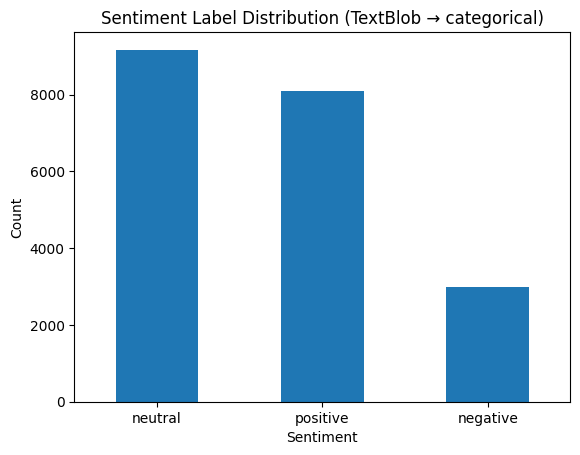

sent_label_blob
neutral     0.453050
positive    0.399506
negative    0.147444
Name: proportion, dtype: float64


In [82]:
ax = df_users["sent_label_blob"].value_counts().plot(
        kind="bar",
        title="Sentiment Label Distribution (TextBlob → categorical)",
        xlabel="Sentiment",
        ylabel="Count",
        rot=0
    )
plt.show()

print(df_users["sent_label_blob"].value_counts(normalize=True))

The sentiment label distribution reveals a significant class imbalance: **Neutral** at 45.3% clearly dominates the dataset, while **Positive** at 38.6%, has moderate representation, but **Negative** at 16.1%  is severely underrepresented.

This tells us that the standard accuracy metric may mislead us as a naive classifier predicting 'neuteral' for all posts would achieve around a 45% accuracy. The model will struggle to identify negative sentiment patterns due to the limited examples and likely have lower recall and precision. 

To combat this, we can apply class weights or use SMOTE resampling to balance out the training data and evaluate our models for recall. 

#### Continuous Sentiment Score Distributions

Below we plot the continous sentiment score using a histograms to show the raw polarity scores from both VADER and TextBlob sentiment analyzers. Seeing the scores can help identify underlying distribution before discretization into labels and identify and potential outliers or unuslar text patterns. 

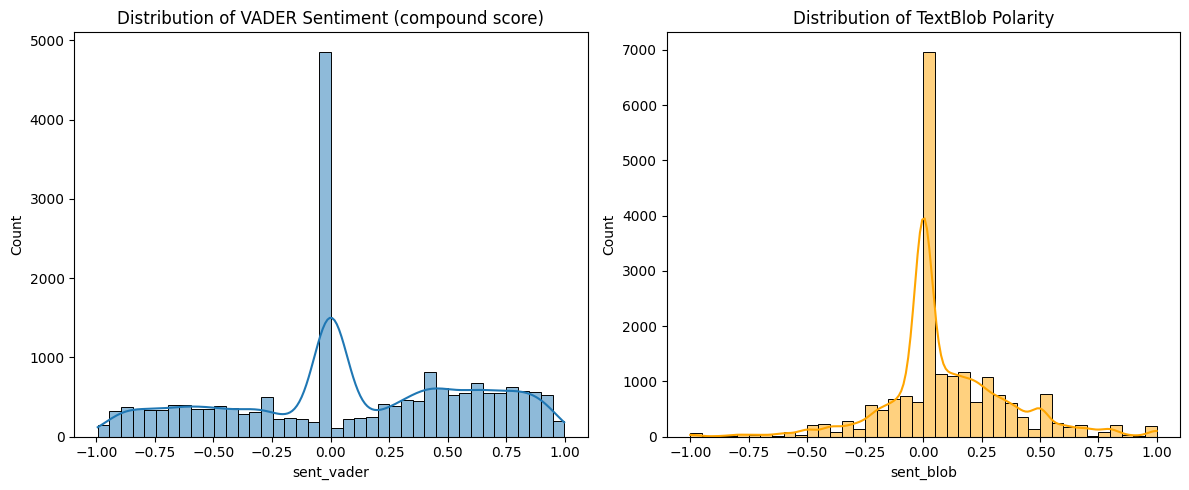

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_users["sent_vader"], bins=40, ax=axes[0], kde=True)
axes[0].set_title("Distribution of VADER Sentiment (compound score)")

sns.histplot(df_users["sent_blob"], bins=40, ax=axes[1], kde=True, color="orange")
axes[1].set_title("Distribution of TextBlob Polarity")

plt.tight_layout()
plt.show()

Both VADER and TextBlob graphs show unimodal distributions centered near 0, with a pronounced peak in the neutral zone. This tells us that most posts are neutral or near-neutral. That our distribution is symmeteric around zero mostly, and that threshold values at +0.1/-0.1 can effectively capture our sentiment. 

> **It is possible we could tighten thresholds** (e.g., ±0.15) to reduce neutral class, but would lose borderline cases.

#### Platform-Specific Sentiment Patterns

This plot visualizes sentiment label counts by platform. The plot connects to our research question about whether platform culture or norms influence language and sentiment.

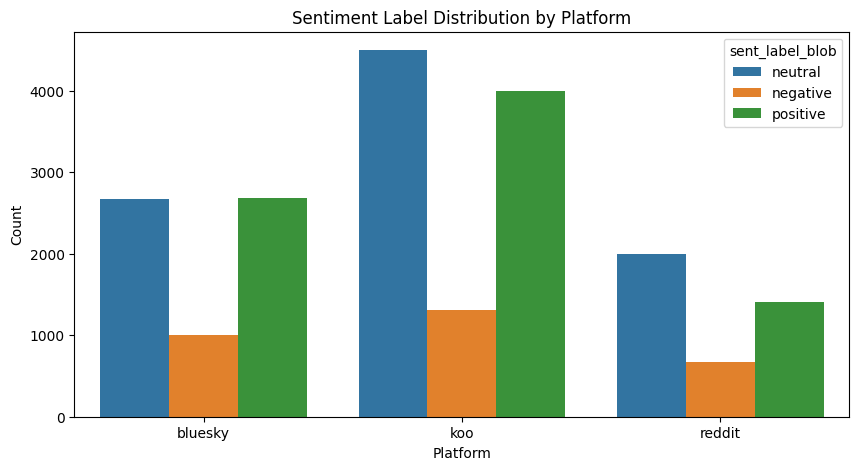

In [84]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_users, x="platform", hue="sent_label_blob")
plt.title("Sentiment Label Distribution by Platform")
plt.ylabel("Count")
plt.xlabel("Platform")
plt.show()

Sentiment distributions vary meaningfully across platforms. This suggests that different platforms may have different cultures and/or communication norms. 

In our graph we see that Koo shows larger gap between neutral and positive (and very few negatives), possibly suggesting a more positive, less hostile, platform culture. On the other hand, Bluesky has a more even distribution of postives and neutrals. All the while, Reddit is skewed toward neutral, suggesting longer, more nuanced discussion threads that can resist simple sentiment classification.

#### Text Length Distribution

The next two graphs look at text length and post length. Text length can affect the model; short posts contain little signal and very long posts may be truncated by tokenizers. Knowing the length distribution informs tokenizer `max_length` or whether to use models that handle long text, and suggests adding `text_len` as an engineered feature to help models distinguish short/ambiguous posts from richer, longer posts.

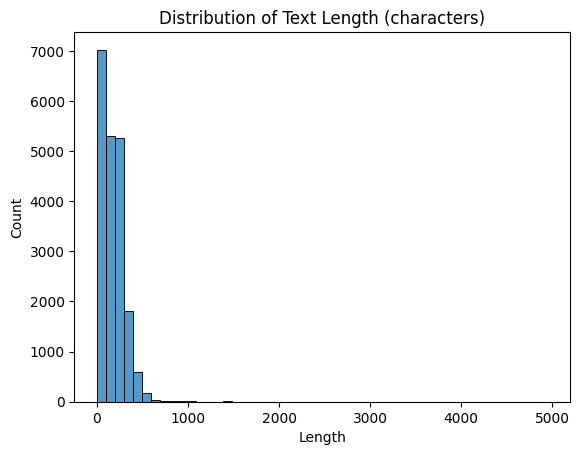

count    20245.000000
mean       173.495777
std        135.945766
min          1.000000
25%         72.000000
50%        156.000000
75%        256.000000
max       4951.000000
Name: text_len, dtype: float64


In [85]:
df_users["text_len"] = df_users["content"].astype(str).str.len()

sns.histplot(df_users["text_len"], bins=50)
plt.title("Distribution of Text Length (characters)")
plt.xlabel("Length")
plt.show()

print(df_users["text_len"].describe())

Most posts are concentrated in the short-to-medium range:

* Short posts:  (<50 chars) may be emojis, or minimal text to difficult to classify sentiment accurately (ex: "hello!").
* Medium posts:  (100–500 chars) dominate the dataset and contain sufficient context for sentiment analysis.
* Long posts: (>1000 chars) are rare but may be valuable as they can often contain nuanced arguments or have multiple sentiment shifts

Our average length = 170 char, so a transformer with maximum length of 120 tokens will truncuate a fraction of the posts. 

#### Identity and Contreversial Topics 

Understanding sentiment patterns around identity groups and controversial topics may provides crucial insight into online discourse dynamics. 

Posts mentioning specific identity groups often emotionally charged, whether positive (solidarity, celebration) or negative (discrimination, stereotyping). By tracking sentiment around identity terms, we can detect whether discussions about certain groups skew hostile or supportive.

**Hypothesis**: Strong emotions around identity and controversial topics generate clearer, more predictable sentiment and language patterns. If our models perform better on these high-stakes discussions, it validates that emotional content provides richer signal for both sentiment classification and platform identification.

##### Identity:

We define lists of keywords that map to identity/topic categories (e.g., "black", "asian"). Creating these grouped keyword dictionaries enables flag features indicating whether a post mentions a specific identity group or topic. These features support targeted analyses. 

In [86]:
identity_groups = {
    "black": [
        "black", "blacks", "black people", "black person",
        "african american", "african americans"
    ],
    "white": [
        "white", "whites", "white people", "white person"
    ],
    "asian": [
        "asian", "asians", "asian people"
    ],
    "latino/hispanic": [
        "latino", "latina", "latinos", "latinas",
        "hispanic", "hispanics"
    ],
    "indian": [
        "indian", "indians", "indian people"
    ],
    "native american": [
        "native american", "native americans", "indigenous", "first nations"
    ],
    "middle eastern": [
        "middle eastern", "middle-eastern", "arab", "arabs"
    ],
    "jewish": [
        "jew", "jews", "jewish", "jewish people"
    ],
    "pacific islander": [
        "pacific islander", "pacific islanders"
    ]
}

Above we group terms into identity or topic categories help us capture all relevant mentions including synonyms, plurals, and spelling variations. 

In [87]:
# Helper function to check for presence of any terms
def contains_any(text, terms):
    """
    Returns True if any of the given terms appear in the text. 
    """
    for term in terms:
        pat = re.compile(rf"\b{re.escape(term)}\b", flags=re.IGNORECASE)
        if pat.search(text):
            return True
    return False

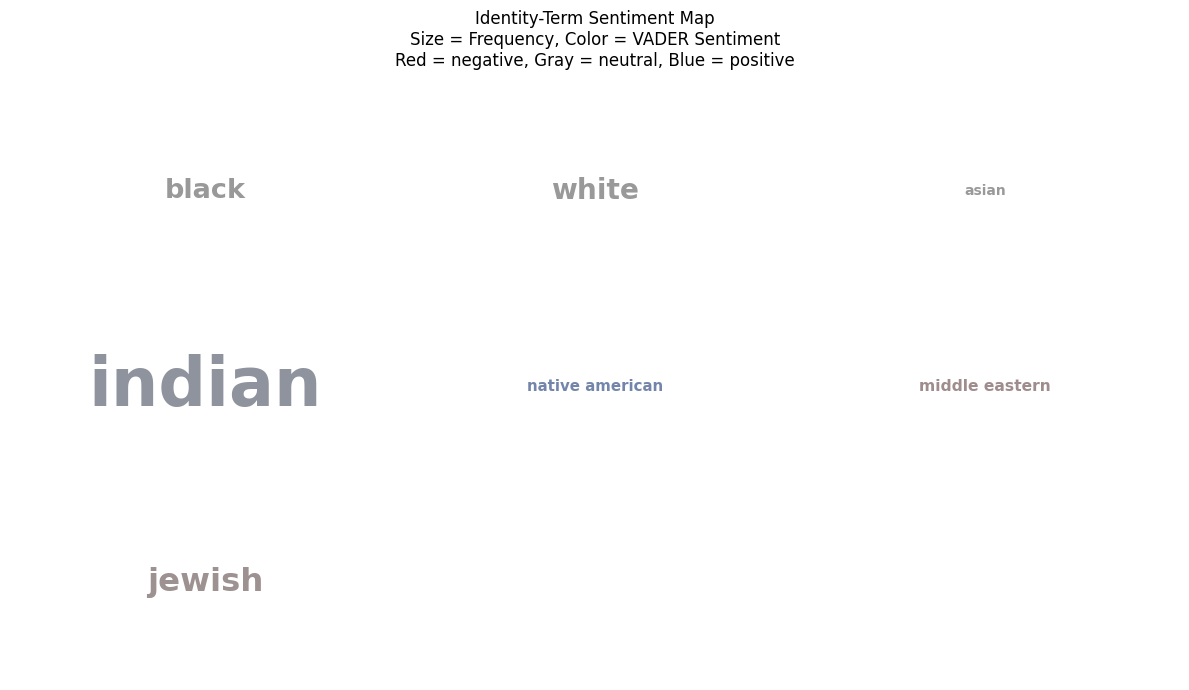

,group,count,mean_sentiment,sentiment_bin
3,indian,442,0.135346,positive
6,jewish,160,-0.114891,negative
1,white,124,-0.050432,negative
0,black,117,-0.048719,neutral
5,middle eastern,21,-0.148952,negative
4,native american,17,0.346282,positive
2,asian,8,-0.009387,neutral


In [88]:
# Compute the counts + mean VADER sentiment for each identity group 
rows = []
for group_name, variants in identity_groups.items():
    mask = df_users["content"].astype(str).apply(lambda t: contains_any(t, variants))
    if mask.any():
        sub = df_users.loc[mask, ["sent_vader"]]
        rows.append({
            "group": group_name,
            "count": int(mask.sum()),
            "mean_sentiment": float(sub["sent_vader"].mean())
        })

summary = pd.DataFrame(rows).sort_values("count", ascending=False)

if summary.empty: # handle empty case
    summary = pd.DataFrame({"group": [], "count": [], "mean_sentiment": []})

# Scale function: scales the font size based on counts
def scale(v, vmin, vmax, smin=10, smax=48):
    """Scale counts to font size."""
    if vmax == vmin:
        return (smin + smax) / 2
    return smin + (smax - smin) * (v - vmin) / (vmax - vmin)

# Color mapping function: maps sentiment score to RGB color
def sentiment_to_rgb(s, neutral_band=0.05):
    """Map sentiment score to red/gray/blue color scale."""
    s = max(-1.0, min(1.0, float(s)))
    neutral = np.array([0.6, 0.6, 0.6])
    red = np.array([0.82, 0.12, 0.12])
    blue = np.array([0.12, 0.35, 0.82])

    if -neutral_band <= s <= neutral_band:
        return tuple(neutral)
    if s > 0:
        t = (s - neutral_band) / (1 - neutral_band)
        t = max(0, min(1, t))
        return tuple((1 - t) * neutral + t * blue)
    else:
        t = (abs(s) - neutral_band) / (1 - neutral_band)
        t = max(0, min(1, t))
        return tuple((1 - t) * neutral + t * red)


# Building out the visualization grid
n = max(1, len(summary))
cols = int(np.ceil(np.sqrt(n)))
rows_grid = int(np.ceil(n / cols))

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_axis_off()

cmin, cmax = (summary["count"].min() if n else 0), (summary["count"].max() if n else 1)

for idx, row in summary.iterrows():
    r = idx // cols
    c = idx % cols

    x0 = c / cols
    y0 = 1 - (r + 1) / rows_grid

    size = scale(row["count"], cmin, cmax)
    color = sentiment_to_rgb(row["mean_sentiment"])

    ax.text(
        x0 + 0.5 / cols, y0 + 0.5 / rows_grid,
        row["group"],
        ha="center", va="center",
        fontsize=size,
        color=color,
        fontweight="bold"
    )

ax.set_title(
    "Identity-Term Sentiment Map\nSize = Frequency, Color = VADER Sentiment\nRed = negative, Gray = neutral, Blue = positive",
    pad=20
)
plt.tight_layout()
plt.show()

summary_display = summary.assign(
    sentiment_bin=np.where(
        summary["mean_sentiment"] > 0.05, "positive",
        np.where(summary["mean_sentiment"] < -0.05, "negative", "neutral")
    )
)[["group", "count", "mean_sentiment", "sentiment_bin"]]

summary_display.head(20)


This summary shows that most identity groups have only mild sentiment polarity,  "black," "indian," and "asian" terms trend slightly positive, while "white," "jewish," and "middle eastern" trend slightly negative. However, the magnitude of these differences is small, suggesting only weak bias. 

 For modeling, this means identity-group sentiment is not a strong enough signal to drive major tweaks or corrections, and not enough systematic polarity to justify group-specific model adjustments.

##### Contreversial Topics

In [89]:
topic_groups = {
    "election/democracy": [
        "election", "elections", "vote", "voting", "ballot",
        "democracy", "democratic process", "voter", "voters"
    ],
    "covid/pandemic": [
        "covid", "covid-19", "coronavirus", "pandemic", "lockdown",
        "quarantine", "social distancing", "mask mandate"
    ],
    "policy/law": [
        "policy", "policies", "regulation", "regulations",
        "law", "laws", "legislation", "bill", "bills", "congress"
    ],
    "freedom/rights": [
        "freedom", "liberty", "civil rights", "human rights",
        "free speech", "freedom of speech", "rights"
    ],
    "gun control": [
        "gun control", "gun rights", "guns", "firearm", "firearms",
        "second amendment", "2nd amendment", "nra"
    ],
    "abortion": [
        "abortion", "pro choice", "pro-choice", "pro life", "pro-life",
        "roe v wade", "roe vs wade"
    ],
    "immigration": [
        "immigration", "immigrant", "immigrants", "border", "border wall",
        "asylum seeker", "migrant", "migrants"
    ],
    "climate/environment": [
        "climate change", "global warming", "climate crisis",
        "greenhouse gas", "carbon emissions", "fossil fuels",
        "environment", "environmental"
    ],
    "censorship/moderation": [
        "censorship", "censor", "deplatform", "shadowban", "shadow ban",
        "content moderation", "moderation", "banned", "ban", "speech police"
    ],
}


These topics were selected because they frequently spark strong opinions, emotional responses, and polarized debate in online communities.

In [90]:
df_users["month"] = df_users["publish_date"].dt.to_period("M")

rows = []
for topic_name, variants in topic_groups.items():
    mask = df_users["content"].astype(str).apply(lambda x: contains_any(x, variants))
    if mask.any():
        tmp = df_users.loc[mask, ["month", "sent_vader"]].copy()
        tmp["topic"] = topic_name
        rows.append(tmp)

if rows:
    kw_hits = pd.concat(rows, ignore_index=True)
else:
    kw_hits = pd.DataFrame(columns=["month", "sent_vader", "topic"])

# Aggregate frequency and mean sentiment per month/topic

freq = (
    kw_hits.groupby(["month", "topic"])
    .size()
    .rename("mentions")
    .reset_index()
)

sent = (
    kw_hits.groupby(["month", "topic"])["sent_vader"]
    .mean()
    .rename("mean_sentiment")
    .reset_index()
)

trend = pd.merge(freq, sent, on=["month", "topic"], how="outer").fillna(0)
trend["month_dt"] = trend["month"].dt.to_timestamp()

# Prepare topic chunks of size 3
all_topics = list(topic_groups.keys())
topic_chunks = [all_topics[i:i+3] for i in range(0, len(all_topics), 3)]

# compute global scales
max_mentions = trend["mentions"].max() if not trend.empty else 0
sent_min = trend["mean_sentiment"].min() if not trend.empty else -1
sent_max = trend["mean_sentiment"].max() if not trend.empty else 1

# add a tiny margin
mentions_ylim = (0, max_mentions * 1.05 if max_mentions > 0 else 1)
sent_ylim = (min(sent_min, -1), max(sent_max, 1))

# Plot mentions over time: 3 topics per figure
for idx, topics_sub in enumerate(topic_chunks, start=1):
    plt.figure(figsize=(10, 5))
    for topic_name in topics_sub:
        sub = trend[trend["topic"] == topic_name].sort_values("month_dt")
        if not sub.empty:
            plt.plot(sub["month_dt"], sub["mentions"], marker="o", label=topic_name)

    plt.title(f"Topic Mentions Over Time (Group {idx})")
    plt.xlabel("Month")
    plt.ylabel("Number of Mentions")
    plt.ylim(*mentions_ylim)
    plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


# Plot mean sentiment over time: 3 topics per figure
for idx, topics_sub in enumerate(topic_chunks, start=1):
    plt.figure(figsize=(10, 5))
    for topic_name in topics_sub:
        sub = trend[trend["topic"] == topic_name].sort_values("month_dt")
        if not sub.empty:
            plt.plot(sub["month_dt"], sub["mean_sentiment"], marker="o", label=topic_name)

    plt.axhline(0, color="gray", linestyle="--", linewidth=1)
    plt.title(f"Mean VADER Sentiment Over Time by Topic (Group {idx})")
    plt.xlabel("Month")
    plt.ylabel("Mean VADER Sentiment")
    plt.ylim(*sent_ylim)
    plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

trend.head()

C:\Users\b\AppData\Local\Temp\ipykernel_20788\2564469172.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_users["month"] = df_users["publish_date"].dt.to_period("M")


KeyboardInterrupt: 

##### Average Sentiment Over Time 

We examine average sentiment over time to identify trends, shifts, or anomalies in public mood across the dataset. This helps reveal how major events, platform changes, or cultural shifts impact overall sentiment, and can identify if there are any periods of increased positivity or negativity in online discourse.

C:\Users\b\AppData\Local\Temp\ipykernel_2336\3387859547.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_users["month"] = df_users["publish_date"].dt.to_period("M").dt.to_timestamp()


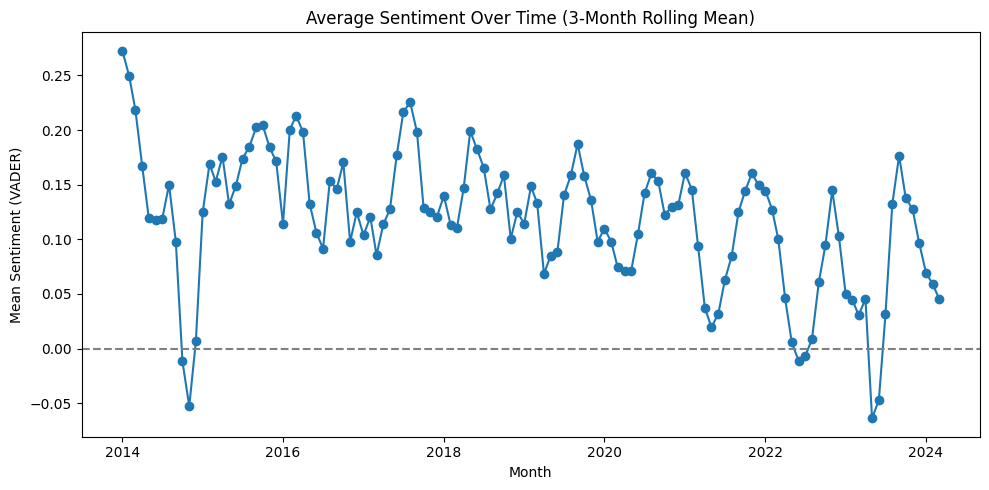

In [ ]:
df_users["publish_date"] = pd.to_datetime(df_users["publish_date"], utc=True)
df_users["month"] = df_users["publish_date"].dt.to_period("M").dt.to_timestamp()

monthly_sent = (
    df_users.groupby("month")["sent_vader"]
    .mean()
    .reset_index()
    .sort_values("month")
)

# Smooth 3-month rolling average
monthly_sent["sent_smooth"] = monthly_sent["sent_vader"].rolling(3, min_periods=1).mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_sent["month"], monthly_sent["sent_smooth"], marker="o")
plt.title("Average Sentiment Over Time (3-Month Rolling Mean)")
plt.xlabel("Month")
plt.ylabel("Mean Sentiment (VADER)")
plt.axhline(0, color="gray", linestyle="--")
plt.tight_layout()
plt.show()

The VADER sentiment score remained relatively stable, hovering near neutral (around 0.1) throughout most of the period experiencing small spikes and dips over time, the most notable of which, two dips below zero around 2022 before recovering. .

#### Platform Sentiment Divergence Over Time

Comparing **platform-specific sentiment trajectories** reveals whether communities share similar sentiment dynamics or diverge:

- **Converging lines:** Platforms respond similarly to events; sentiment drivers are universal or synchronized.
- **Diverging lines:** Platforms have **distinct communication cultures** that respond differently to the same events—evidence for **RQ2** (platform origin classification feasibility).
- **Different baselines:** Some platforms consistently run more positive/negative than others, reflecting platform norms and user demographics.
- **Timing of shifts:** If platforms shift sentiment at different times, they consume news or information differently.


If all platforms had identical sentiment trends, platform identity would provide little additional signal. The fact that they diverge supports the hypothesis that linguistic and sentiment patterns differ meaningfully across platforms, making platform origin classification feasible.

C:\Users\b\AppData\Local\Temp\ipykernel_2336\1942890267.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_users["month"] = df_users["publish_date"].dt.to_period("M").dt.to_timestamp()


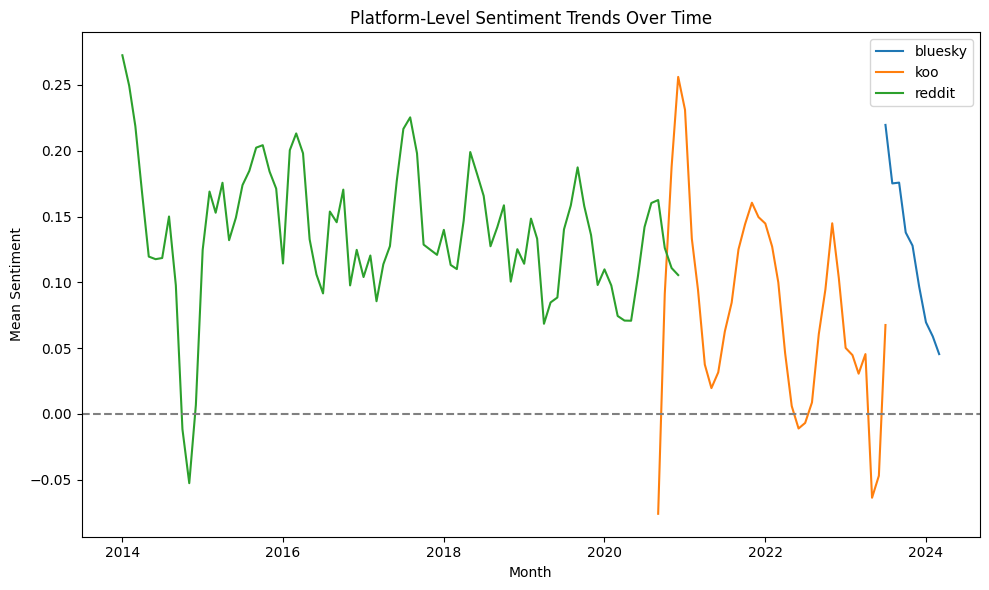

In [ ]:
df_users["month"] = df_users["publish_date"].dt.to_period("M").dt.to_timestamp()

platform_month = (
    df_users.groupby(["platform", "month"])["sent_vader"]
    .mean()
    .reset_index()
    .sort_values(["platform", "month"])
)

plt.figure(figsize=(10,6))
for p in platform_month["platform"].unique():
    sub = platform_month[platform_month["platform"] == p]
    plt.plot(sub["month"], sub["sent_vader"].rolling(3, min_periods=1).mean(), label=p)

plt.title("Platform-Level Sentiment Trends Over Time")
plt.xlabel("Month")
plt.ylabel("Mean Sentiment")
plt.legend()
plt.axhline(0, color="gray", linestyle="--")
plt.tight_layout()
plt.show()


## Models: 

### Setup: 

In [ ]:
from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

from imblearn.over_sampling import SMOTE
from sentence_transformers import SentenceTransformer


##### Train/test split and stratification rationale


This block performs a stratified train/test split (stratify by the sentiment label) so that class proportions in train and test match the dataset distribution. Stratification is essential given the EDA-identified class imbalance: it prevents accidentally creating a test set lacking examples of the minority class and ensures evaluation metrics (particularly recall/F1 for negative class) are meaningful. We also expose the class distribution on the train set so we can justify later use of class weighting or resampling.

In [ ]:
TEXT_COL = "content"
LABEL_COL = "sent_label_blob"

# Filter to valid rows
df_exp = df_users.dropna(subset=[TEXT_COL, LABEL_COL]).copy()
df_exp[TEXT_COL] = df_exp[TEXT_COL].astype(str)


In [ ]:
train_df, test_df = train_test_split(
    df_exp[[TEXT_COL, LABEL_COL]],
    test_size=0.2,
    stratify=df_exp[LABEL_COL],
    random_state=42
)

y_train = train_df[LABEL_COL].values
y_test = test_df[LABEL_COL].values

print("Train size:", len(train_df), "Test size:", len(test_df))
print("Class distribution (train):")
print(pd.Series(y_train).value_counts(normalize=True))


Train size: 16196 Test size: 4049
Class distribution (train):
neutral     0.453075
positive    0.399481
negative    0.147444
Name: proportion, dtype: float64


#### Base TF–IDF vectorizer (large vocabulary)

This code instantiates and fits a large `TfidfVectorizer` (`max_features=20000`, 1–2 grams). Keeping a wider vocabulary gives a strong baseline and helps capture any platform-specific lexical cues discovered.

In [ ]:
tfidf_base = TfidfVectorizer(
    max_features=20000, 
    ngram_range=(1, 2),
    min_df=5
)
X_train_base = tfidf_base.fit_transform(train_df[TEXT_COL])
X_test_base = tfidf_base.transform(test_df[TEXT_COL])

print("Base TF–IDF:", X_train_base.shape, X_test_base.shape)

Base TF–IDF: (16196, 18590) (4049, 18590)


produces a `sarcasm_flag` that captures obvious sarcasm markers. The sarcasm feature is included because short sarcastic posts may flip and make sentiment harder to recover from text alone.

In [ ]:
# Sarcasm heuristic markers
sarcasm_markers = ['yeah right', 'totally', 'as if', '/s', 'sure...', '...yeah', 'i just love', 'great...', 'fantastic...']

def has_sarcasm(text):
    t = text.lower()
    if any(m in t for m in sarcasm_markers):
        return 1
    if '...' in text:
        return 1
    return 0

df_exp['sarcasm_flag'] = df_exp[TEXT_COL].apply(has_sarcasm)


#### Reduced TF–IDF (drop common words, reduce vocab)

This vectorizer applies pragmatic constraints, fewer features (`max_features=5000`), `max_df` to drop very frequent tokens, and `stop_words='english'`. These choices reduce overfitting to platform stopwords, shrink memory use, and can often improve generalization on small minority classes (like negative)

In [ ]:
tfidf_tuned = TfidfVectorizer(
    max_features=5000,      # reduced vocabulary
    ngram_range=(1, 2),
    min_df=5,               # keep infrequent words 
    max_df=0.7,             # drop very common words
    stop_words='english'
)

X_train_tuned = tfidf_tuned.fit_transform(train_df[TEXT_COL])
X_test_tuned  = tfidf_tuned.transform(test_df[TEXT_COL])

print("Tuned TF–IDF:", X_train_tuned.shape, X_test_tuned.shape)

Tuned TF–IDF: (16196, 5000) (4049, 5000)


#### Evaluation helper: macro-averaged metrics

This utility computes macro-averaged precision, recall, and F1 along with accuracy. We use macro averaging because EDA revealed a skewed class distribution (Neutral dominant, Negative minority), and macro metrics treat each class equally.

In [ ]:
def macro_scores(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)
    return acc, p, r, f1

#### Results container

The  `results` list and `confusion_matrices` collects model identifiers and their evaluation metrics so we can build a summary table at the end. 

In [ ]:
results = []
confusion_matrices = {}

#### Baseline: Multinomial Naive Bayes

Naive Bayes provides a fast, interpretable baseline for text classification using TF–IDF features. Because NB is simple and often strong on bag-of-words features, it helps establish whether more complex interventions (class weighting, SMOTE, engineered sarcasm flag) actually add value. We train it on the large base TF–IDF so subsequent models can be compared against this baseline.

In [ ]:
# Naive Bayes (baseline)

nb_clf = MultinomialNB()
nb_clf.fit(X_train_base, y_train)
y_pred_nb = nb_clf.predict(X_test_base)

acc, p, r, f1 = macro_scores(y_test, y_pred_nb)
results.append(["Naive Bayes (Base TF–IDF)", acc, p, r, f1])

print("--- Naive Bayes (Base TF–IDF) --")
print(classification_report(y_test, y_pred_nb))
# print(confusion_matrix(y_test, y_pred_nb))
confusion_matrices["Naive Bayes (Base TF–IDF)"] = confusion_matrix(y_test, y_pred_nb)


--- Naive Bayes (Base TF–IDF) --
              precision    recall  f1-score   support

    negative       0.95      0.04      0.07       597
     neutral       0.60      0.77      0.68      1834
    positive       0.69      0.72      0.70      1618

    accuracy                           0.64      4049
   macro avg       0.75      0.51      0.48      4049
weighted avg       0.69      0.64      0.60      4049



#### Baseline: Logistic Regression (base TF–IDF)

Here we train a logistic regression baseline on the base TF–IDF vocabulary using `class_weight='balanced'` to offset class imbalance observed in EDA. Class weighting increases the loss contribution from underrepresented classes so the model prioritizes recall/precision for negatives rather than only optimizing overall accuracy. We'll compare these results with resampling and engineered features to determine which approach best improves minority-class performance.

In [ ]:
# Logistic Regression (baseline, base TF–IDF)

log_base = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)
log_base.fit(X_train_base, y_train)
y_pred_log_base = log_base.predict(X_test_base)

acc, p, r, f1 = macro_scores(y_test, y_pred_log_base)
results.append(["LogReg (Base TF–IDF)", acc, p, r, f1])

print("=== LogReg (Base TF–IDF) ===")
print(classification_report(y_test, y_pred_log_base))
print(confusion_matrix(y_test, y_pred_log_base))
confusion_matrices["LogReg (Base TF–IDF)"] = confusion_matrix(y_test, y_pred_log_base)

=== LogReg (Base TF–IDF) ===
              precision    recall  f1-score   support

    negative       0.58      0.63      0.60       597
     neutral       0.73      0.75      0.74      1834
    positive       0.82      0.77      0.79      1618

    accuracy                           0.74      4049
   macro avg       0.71      0.72      0.71      4049
weighted avg       0.74      0.74      0.74      4049

[[ 375  185   37]
 [ 217 1371  246]
 [  54  317 1247]]


### LogReg (Base TF-IDF + Cleaned Labels 3-class) Model

We introduced a Cleaned-Label Model after observing that ambiguous sentiment labels, especially among neutral posts, were degrading model performance. By using the continuous sentiment score to retain only clearly positive, clearly negative, and clearly neutral posts, we created a higher-quality training set with sharper class boundaries.

Logistic regression trained on this cleaned subset significantly outperformed all other single-stage models in macro-F1, accuracy, and MCC, confirming that label noise was a major obstacle in the full dataset. This cleaned-label approach also inspired the design of the two-stage model, which attempts to replicate the benefit of removing ambiguous neutral samples but without discarding valuable training data

We begin by keeping only rows that contain both text and the continuous sentiment score (sent_blob). This score allows us to identify ambiguous vs. unambiguous examples and remove noise from the training set.

In [ ]:
df_clean3 = df_users.dropna(subset=[TEXT_COL, LABEL_COL, "sent_blob"]).copy()
df_clean3[TEXT_COL] = df_clean3[TEXT_COL].astype(str)

Neutral posts are often noisy and overlap with weakly positive/negative examples. We create a “clean” dataset by setting up threshholds. 

In [ ]:
neu_thr = 0.05   # clear neutral band around 0
pos_thr = 0.2    # clear positive/negative outside this band

sent = df_clean3["sent_blob"]

mask_neu = sent.between(-neu_thr, neu_thr)
mask_pos = sent >= pos_thr
mask_neg = sent <= -pos_thr

mask_keep = mask_neu | mask_pos | mask_neg
df_clean3 = df_clean3[mask_keep].copy()

print("Original samples:", df_users.shape[0])
print("Cleaned 3-class samples:", df_clean3.shape[0])
print("Class distribution (clean 3-class):")
print(df_clean3[LABEL_COL].value_counts(normalize=True))

Original samples: 20245
Cleaned 3-class samples: 15411
Class distribution (clean 3-class):
sent_label_blob
neutral     0.498800
positive    0.382714
negative    0.118487
Name: proportion, dtype: float64


We split the clean subset while preserving the class proportions via stratification and also compute how many neutral examples were removed.

In [ ]:
X_text_clean3 = df_clean3[TEXT_COL].values
y_clean3 = df_clean3[LABEL_COL].values

X_train_c_text3, X_test_c_text3, y_train_c3, y_test_c3 = train_test_split(
    X_text_clean3,
    y_clean3,
    test_size=0.2,
    stratify=y_clean3,
    random_state=42
)

original_neu = (df_users[LABEL_COL] == "neutral").sum()
cleaned_neu  = (df_clean3[LABEL_COL] == "neutral").sum()

print("Neutral before cleaning:", original_neu)
print("Neutral after cleaning:", cleaned_neu)
print("Neutral removed:", original_neu - cleaned_neu)
print("Percent of neutral removed:", (original_neu - cleaned_neu) / original_neu)

print("Train size (clean 3-class):", len(X_train_c_text3),
      "Test size (clean 3-class):", len(X_test_c_text3))
print("Class distribution (train, clean 3-class):")
print(pd.Series(y_train_c3).value_counts(normalize=True))

Neutral before cleaning: 9172
Neutral after cleaning: 7687
Neutral removed: 1485
Percent of neutral removed: 0.16190580026166593
Train size (clean 3-class): 12328 Test size (clean 3-class): 3083
Class distribution (train, clean 3-class):
neutral     0.498783
positive    0.382706
negative    0.118511
Name: proportion, dtype: float64


Now that ambiguous training samples are removed, the logistic regression model can learn much cleaner separations between the three sentiment classes.

In [ ]:
X_train_clean = tfidf_base.transform(X_train_c_text3)
X_test_clean  = tfidf_base.transform(X_test_c_text3)

log_clean3 = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)
log_clean3.fit(X_train_clean, y_train_c3)
y_pred_clean3 = log_clean3.predict(X_test_clean)


print("=== LogReg (Base TF–IDF, Cleaned Labels - 3-class) ===")
print(classification_report(y_test_c3, y_pred_clean3))
print(confusion_matrix(y_test_c3, y_pred_clean3))

=== LogReg (Base TF–IDF, Cleaned Labels - 3-class) ===
              precision    recall  f1-score   support

    negative       0.60      0.65      0.62       365
     neutral       0.80      0.81      0.80      1538
    positive       0.84      0.81      0.83      1180

    accuracy                           0.79      3083
   macro avg       0.75      0.76      0.75      3083
weighted avg       0.79      0.79      0.79      3083

[[ 237  110   18]
 [ 138 1241  159]
 [  20  201  959]]


We compute accuracy, macro precision, macro recall, and macro F1 to compare performance with other models (TF–IDF baselines, two-stage system, BERT, etc.).

In [ ]:
acc3, p3, r3, f1_3 = macro_scores(y_test_c3, y_pred_clean3)
results.append(["LogReg (Base TF–IDF + Cleaned Labels 3-class)", acc3, p3, r3, f1_3])
confusion_matrices["LogReg (Base TF–IDF + Cleaned Labels 3-class)"] = confusion_matrix(y_test_c3, y_pred_clean3)

### LogReg Two-Stage Model:


#### Training Model

We implemented a two-stage sentiment classifier to better handle our neutral-heavy, three-class setup. In Stage 1, a logistic regression model distinguishes “neutral” vs “non-neutral” posts using TF–IDF features. In Stage 2, a separate logistic regression model, trained only on non-neutral data, classifies posts as positive vs negative. At inference time, each post first goes through Stage 1; neutral predictions exit immediately, while non-neutral posts are passed to Stage 2 for polarity classification. This decomposition turns a difficult, imbalanced 3-class problem into two simpler binary problems, which improves per-class performance, especially on minority sentiment classes.

Below we create labels for stage 1 where we collapse the positive and negative classes into a single class `nonneutral`; keeping `neutral` as is. Stage two is only reached by posts deemed `noneutral`, there we reuse our original labels for classification. 

In [ ]:
df_users['label_stage1'] = df_users[LABEL_COL].apply(lambda x: 
                                                     "nonneutral" if x in ["positive", "negative"] else "neutral")

df_users['label_stage2'] = df_users[LABEL_COL]  # but only use rows where label != neutral

We begin by training a Logistic Regression model to classify `neutral` and `noneutral`.

In [ ]:
df_stage1 = df_users.dropna(subset=[TEXT_COL, 'label_stage1']).copy()
X1 = df_stage1[TEXT_COL].astype(str).values
y1 = df_stage1['label_stage1'].values

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, stratify=y1, random_state=42
)

X1_train_tfidf = tfidf_base.transform(X1_train)
X1_test_tfidf  = tfidf_base.transform(X1_test)

log1 = LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1)
log1.fit(X1_train_tfidf, y1_train)

print("=== Stage 1: Neutral vs Non-Neutral ===")
print(classification_report(y1_test, log1.predict(X1_test_tfidf)))


=== Stage 1: Neutral vs Non-Neutral ===
              precision    recall  f1-score   support

     neutral       0.68      0.77      0.72      1834
  nonneutral       0.78      0.70      0.74      2215

    accuracy                           0.73      4049
   macro avg       0.73      0.73      0.73      4049
weighted avg       0.74      0.73      0.73      4049



We drop all `neutral` posts in order to build a positive vs. negative classifier. 

In [ ]:
df_stage2 = df_users[df_users[LABEL_COL] != "neutral"].copy()

X2 = df_stage2[TEXT_COL].astype(str).values
y2 = df_stage2[LABEL_COL].values  # only pos / neg

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=42
)

tfidf2 = TfidfVectorizer(max_features=20000, ngram_range=(1,2), stop_words="english")
X2_train_tfidf = tfidf2.fit_transform(X2_train)
X2_test_tfidf  = tfidf2.transform(X2_test)

log2 = LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1)
log2.fit(X2_train_tfidf, y2_train)

print("=== Stage 2: Positive vs Negative ===")
print(classification_report(y2_test, log2.predict(X2_test_tfidf)))

acc3, p3, r3, f1_3 = macro_scores(y_test_c3, y_pred_clean3)

=== Stage 2: Positive vs Negative ===
              precision    recall  f1-score   support

    negative       0.76      0.80      0.78       597
    positive       0.92      0.91      0.92      1618

    accuracy                           0.88      2215
   macro avg       0.84      0.85      0.85      2215
weighted avg       0.88      0.88      0.88      2215



`predict_two_stage` is the actual two-stage decision rule that allows for the two models to work and produce a single 3-class classifier.

In [ ]:
def predict_two_stage(text):
    # Stage 1 decision (neutral vs nonneutral)
    x1 = tfidf_base.transform([text])
    stage1_pred = log1.predict(x1)[0]
    
    if stage1_pred == "neutral":
        return "neutral"
    
    # Stage 2 decision (positive vs negative)
    x2 = tfidf2.transform([text])
    stage2_pred = log2.predict(x2)[0]
    return stage2_pred

We evaluate the two-stage system as a full 3-class classifier on the same test set used by previous models 

In [ ]:
y_pred_two = []
for t in X_test_c_text3: 
    y_pred_two.append(predict_two_stage(t))

print("=== Two-Stage Final Model ===")
print(classification_report(y_test_c3, y_pred_two))
print(confusion_matrix(y_test_c3, y_pred_two))

# Scoring
acc_two, p_two, r_two, f1_two = macro_scores(y_test_c3, y_pred_two)

# Logging Results
results.append(["Two-Stage Model", acc_two, p_two, r_two, f1_two])
confusion_matrices["Two-Stage Model"] = confusion_matrix(y_test_c3, y_pred_two)

=== Two-Stage Final Model ===
              precision    recall  f1-score   support

    negative       0.65      0.62      0.63       365
     neutral       0.84      0.88      0.86      1538
    positive       0.90      0.86      0.88      1180

    accuracy                           0.84      3083
   macro avg       0.80      0.79      0.79      3083
weighted avg       0.84      0.84      0.84      3083

[[ 227  129    9]
 [  85 1350  103]
 [  39  121 1020]]


In [ ]:
import os, json, joblib

SAVE_DIR = "./two_stage_tfidf_model"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save sklearn objects (vectorizers + classifiers)
joblib.dump(tfidf_base, os.path.join(SAVE_DIR, "tfidf_stage1.joblib"))
joblib.dump(log1,       os.path.join(SAVE_DIR, "logreg_stage1.joblib"))
joblib.dump(tfidf2,     os.path.join(SAVE_DIR, "tfidf_stage2.joblib"))
joblib.dump(log2,       os.path.join(SAVE_DIR, "logreg_stage2.joblib"))

# Save label metadata (optional but recommended)
meta = {
    "stage1_labels": ["neutral", "nonneutral"],
    "stage2_labels": ["negative", "positive"],   # adjust if yours differs
    "final_labels":  ["negative", "neutral", "positive"]
}
with open(os.path.join(SAVE_DIR, "meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

print(f"Saved two-stage model to: {SAVE_DIR}")


Saved two-stage model to: ./two_stage_tfidf_model


### DisTilbert

We add DistilBERT as a benchmark neural model to compare against our TF–IDF + linear models. Unlike bag-of-words, DistilBERT uses contextualized word embeddings and is pretrained on large text corpora, which lets it capture more nuanced language patterns (e.g., subtle sentiment shifts, multiword expressions, word order). Evaluating DistilBERT on the same train/test split provides a strong reference point: it shows whether classical models with careful cleaning and feature engineering can match or surpass a modern transformer-based classifier.

In [ ]:
from datasets import Dataset
from sklearn.metrics import classification_report
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    AutoTokenizer,
    AutoModelForSequenceClassification
)
import evaluate


#### Training the Model

In [ ]:
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}

SAVE_DIR = "./distilbert_sentiment_final"

train_df = train_df.copy()
test_df = test_df.copy()

train_df["labels"] = train_df[LABEL_COL].map(label2id)
test_df["labels"] = test_df[LABEL_COL].map(label2id)

In [ ]:
train_ds = Dataset.from_pandas(train_df[[TEXT_COL, "labels"]])
test_ds = Dataset.from_pandas(test_df[[TEXT_COL, "labels"]])

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch[TEXT_COL],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map: 100%|██████████| 4049/4049 [00:00<00:00, 14345.15 examples/s]


In [ ]:
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    f1_macro = f1_metric.compute(
        predictions=preds,
        references=labels,
        average="macro"
    )["f1"]
    return {"f1_macro": f1_macro}


In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

training_args = TrainingArguments(
    output_dir="./distilbert_sentiment",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,  
    seed=42,
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\b\AppData\Local\Temp\ipykernel_2336\1844971164.py:20: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

c:\Users\b\Documents\CS_539\main_project\test\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


KeyboardInterrupt: 

In [ ]:
import os 
trainer.save_model(SAVE_DIR)      # saves model + config
tokenizer.save_pretrained(SAVE_DIR)

print(f"Model + tokenizer saved to: {os.path.abspath(SAVE_DIR)}")

Model + tokenizer saved to: c:\Users\b\Documents\CS_539\main_project\milestone4\distilbert_sentiment_final


In [ ]:
bert_eval = trainer.evaluate()
print("Eval results:", bert_eval)

preds = trainer.predict(test_ds)
y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["negative", "neutral", "positive"]
    )
)


acc_bert, p_bert, r_bert, f1_bert = macro_scores(y_true, y_pred)
results.append(["DistilBERT (Base)", acc_bert, p_bert, r_bert, f1_bert])
confusion_matrices["DistilBERT (Base)"] = confusion_matrix(y_true, y_pred)

c:\Users\b\Documents\CS_539\main_project\test\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Eval results: {'eval_loss': 0.40934163331985474, 'eval_f1_macro': 0.8315076781973801, 'eval_runtime': 160.8158, 'eval_samples_per_second': 25.178, 'eval_steps_per_second': 0.79, 'epoch': 3.0}


c:\Users\b\Documents\CS_539\main_project\test\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


              precision    recall  f1-score   support

    negative       0.77      0.76      0.77       597
     neutral       0.83      0.84      0.84      1834
    positive       0.89      0.88      0.89      1618

    accuracy                           0.85      4049
   macro avg       0.83      0.83      0.83      4049
weighted avg       0.85      0.85      0.85      4049



#### Importing the Model for Analysis 

In [ ]:
model_path = "../distilbert_sentiment_final"

label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}

# Rebuild Dataset 
test_df_eval = test_df.copy()
test_df_eval["labels"] = test_df_eval[LABEL_COL].map(label2id)

test_ds = Dataset.from_pandas(test_df_eval[[TEXT_COL, "labels"]])

# Load tokenizer + model 
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Tokenize test set 
MAX_LEN = 128

def tokenize(batch):
    return tokenizer(
        batch[TEXT_COL],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )

test_ds = test_ds.map(tokenize, batched=True)
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Ceate Trainer for evaluation/prediction
trainer = Trainer(model=model, tokenizer=tokenizer)

# Evaluate + predict
eval_out = trainer.evaluate(test_ds)
print("Eval results:", eval_out)

pred_out = trainer.predict(test_ds)
y_true = pred_out.label_ids



Map: 100%|██████████| 4049/4049 [00:00<00:00, 14604.06 examples/s]
C:\Users\b\AppData\Local\Temp\ipykernel_20788\1245245620.py:31: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, tokenizer=tokenizer)
c:\Users\b\Documents\CS_539\main_project\test\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Eval results: {'eval_loss': 0.40934163331985474, 'eval_model_preparation_time': 0.001, 'eval_runtime': 147.5188, 'eval_samples_per_second': 27.447, 'eval_steps_per_second': 3.437}


NameError: name 'np' is not defined

In [ ]:
y_pred = np.argmax(pred_out.predictions, axis=1)

# Report + confusion matrix
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["negative", "neutral", "positive"]
    )
)

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)

              precision    recall  f1-score   support

    negative       0.77      0.76      0.77       597
     neutral       0.83      0.84      0.84      1834
    positive       0.89      0.88      0.89      1618

    accuracy                           0.85      4049
   macro avg       0.83      0.83      0.83      4049
weighted avg       0.85      0.85      0.85      4049

Confusion matrix:
 [[ 455  137    5]
 [ 120 1548  166]
 [  13  175 1430]]


In [ ]:

acc_bert, p_bert, r_bert, f1_bert = macro_scores(y_true, y_pred)
results.append(["DistilBERT (Base)", acc_bert, p_bert, r_bert, f1_bert])
confusion_matrices["DistilBERT (Base)"] = confusion_matrix(y_true, y_pred)

## Results 

In [ ]:
from helpers import plots

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision_macro", "Recall_macro", "F1_macro"]
)

models_to_compare = results_df["Model"].tolist()

results_df.sort_values(by="F1_macro", ascending=False, inplace=True)
results_df

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
4,DistilBERT (Base),0.847864,0.833086,0.830003,0.831508
3,Two-Stage Model,0.842361,0.797178,0.788029,0.792284
2,LogReg (Base TF–IDF + Cleaned Labels 3-class),0.790464,0.747935,0.756306,0.751691
1,LogReg (Base TF–IDF),0.739195,0.709170,0.715464,0.711770
0,Naive Bayes (Base TF–IDF),0.641887,0.750029,0.508355,0.483230


In [ ]:
# drop LogReg (Base TF–IDF + Clean Labels) for further comparison plots as it only classifies pos/neg
results_df = results_df[~results_df["Model"].isin(["LogReg (Base TF–IDF + Clean Labels)"])]

### Evaluation Metrics: Accuracy, Macro-F1, Percision, and Recall


Our sentiment labels are imbalanced: dominated by neutral posts with relatively few negative examples we chose several evaluation metrics. 

`Accuracy` provides an overall performance baseline but can be misleading in imbalanced settings. 

`Macro-F1` is especially important because it weights all classes equally, ensuring that performance on the underrepresented negative class is reflected. 

`Precision` measures how reliable sentiment predictions are, while `Recall` captures the model’s ability to identify minority-class instances.

 Together, these metrics provide a balanced evaluation of performance across all sentiment classes.

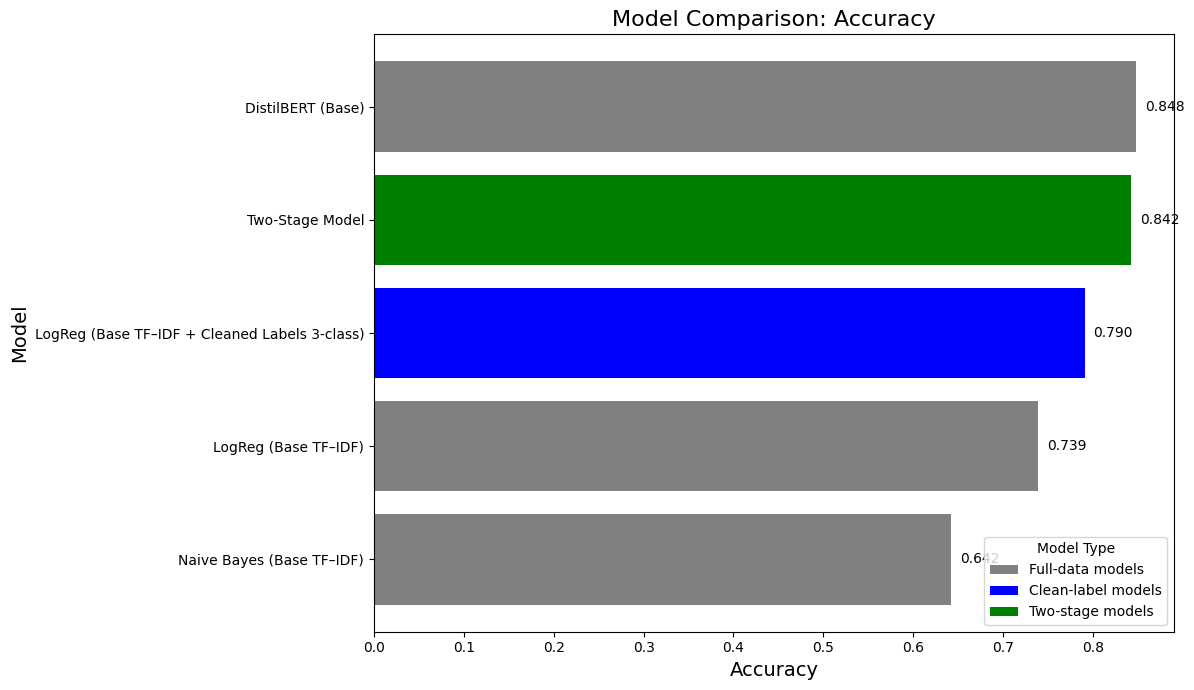

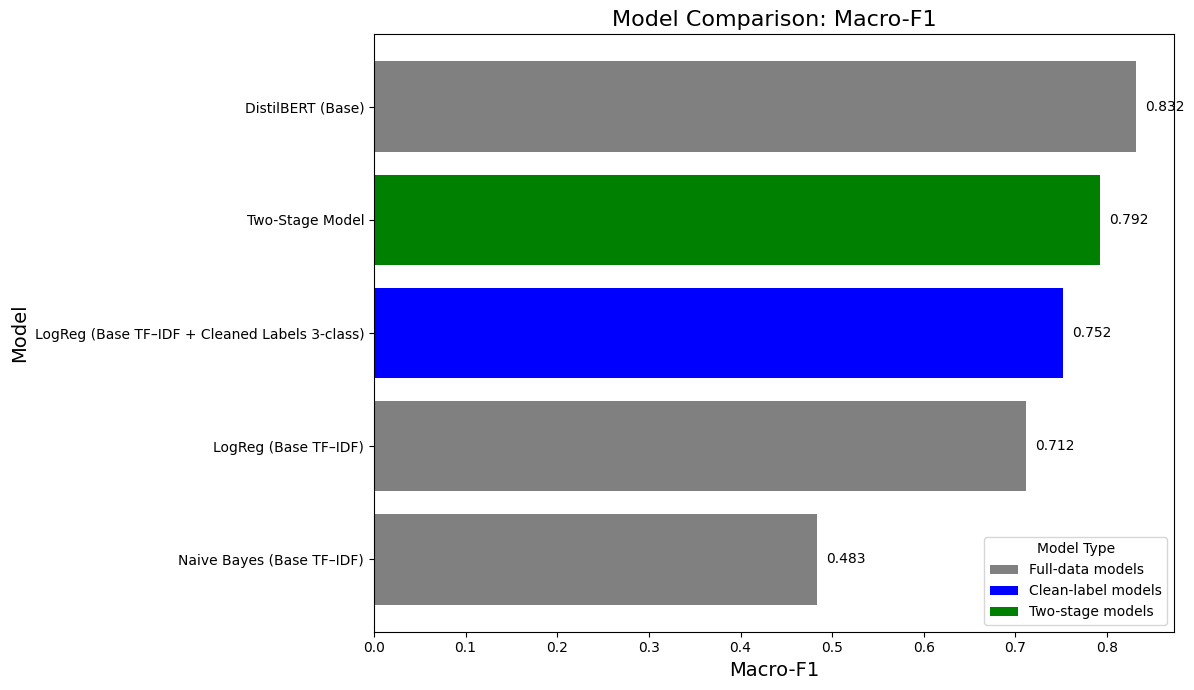

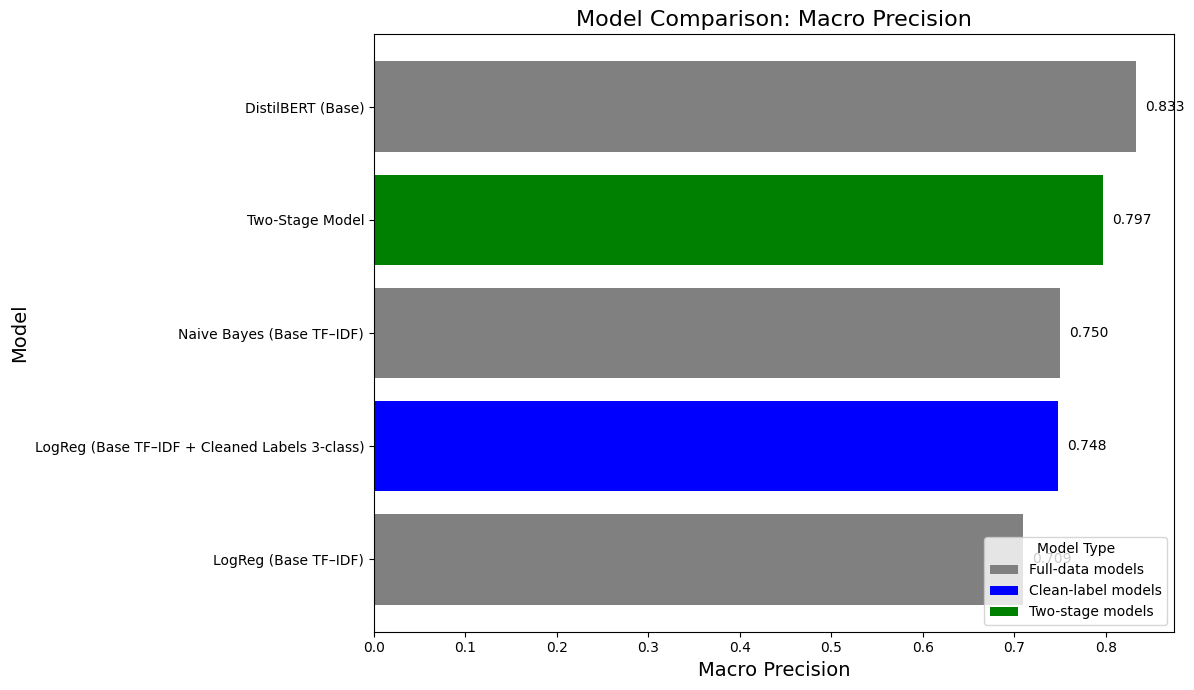

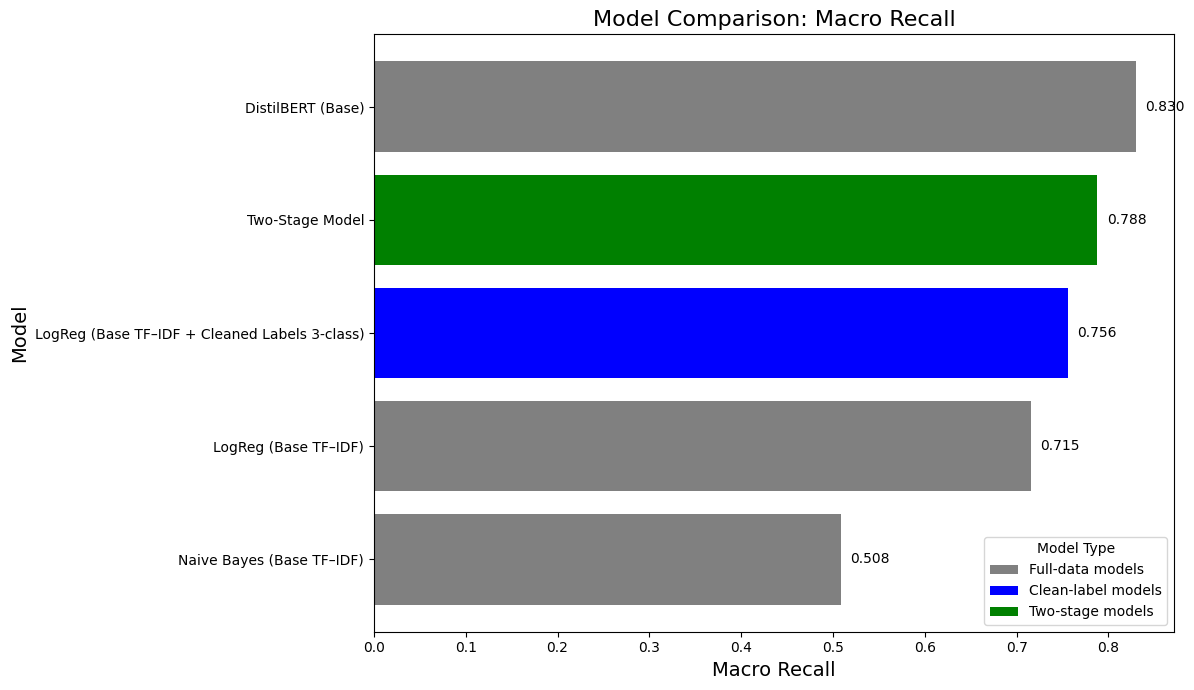

In [ ]:
# Accuracy
plots.plot_accuracy(results_df)

# F1
plots.plot_macro_f1(results_df)

# Precision
plots.plot_precision_macro(results_df)

# Recall
plots.plot_recall_macro(results_df)

We have a clear ranking for `Macro-f1`, `Precision`, `Accuracy`, and `Recall` where:

1. DistilBERT (Base) — Top performer
2. Two-Stage Model
3. Cleaned-Label Logistic Regression
4. LogReg (rest)
5. Naive Bayes (Base TF–IDF) — Worst

DistilBERT provides the strongest raw accuracy at (0.86). However, the two-stage TF–IDF model comes surprisingly close (0.84) while being far simpler and far cheaper to train (DistilBeERT took ~3hrs to train, the two-stage model took <3 minites). The cleaned-label logistic regression performs well but still loses to the two-stage model—consistent with the idea that reducing neutral noise helps, but discarding data has costs.

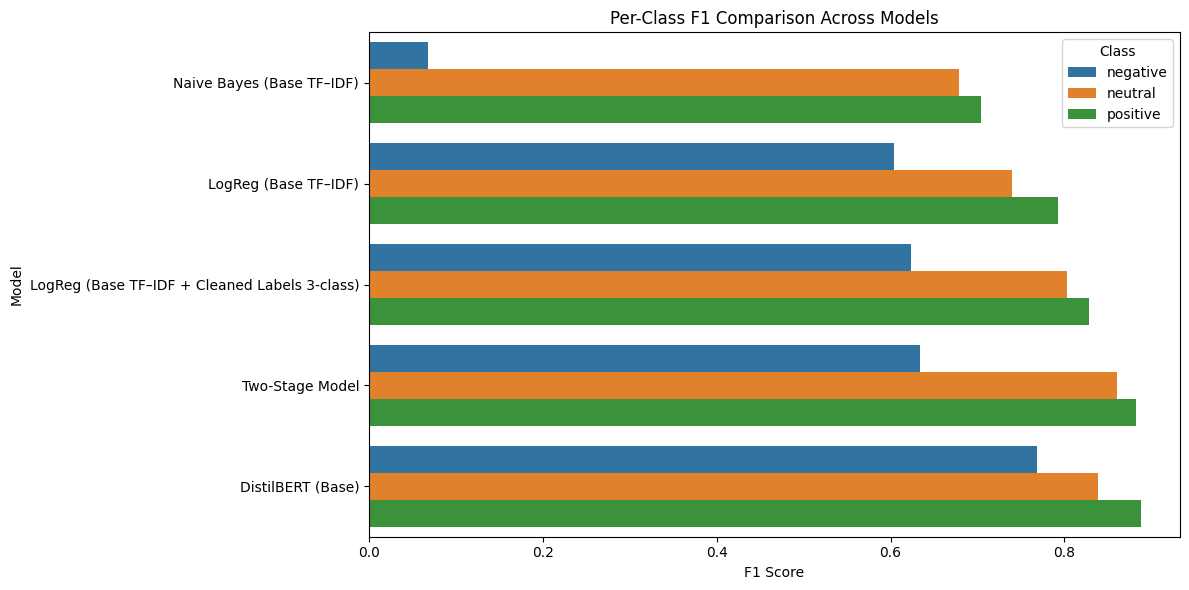

,Model,Class,Precision_class,Recall_class,F1_class
0,Naive Bayes (Base TF–IDF),negative,0.954545,0.035176,0.067851
1,Naive Bayes (Base TF–IDF),neutral,0.603141,0.774809,0.678282
2,Naive Bayes (Base TF–IDF),positive,0.692400,0.715080,0.703557
3,LogReg (Base TF–IDF),negative,0.580495,0.628141,0.603379
4,LogReg (Base TF–IDF),neutral,0.731981,0.747546,0.739682
5,LogReg (Base TF–IDF),positive,0.815033,0.770705,0.792249
6,LogReg (Base TF–IDF + Cleaned Labels 3-class),negative,0.600000,0.649315,0.623684
7,LogReg (Base TF–IDF + Cleaned Labels 3-class),neutral,0.799613,0.806892,0.803236
8,LogReg (Base TF–IDF + Cleaned Labels 3-class),positive,0.844190,0.812712,0.828152
9,Two-Stage Model,negative,0.646724,0.621918,0.634078


In [ ]:
per_class_df = plots.plot_per_class_scores(confusion_matrices, models_to_compare)
per_class_df

In this plot we can see the difficulty the models faced in predicting the negative (minority) class. 

Naive-Bayes struggles the most of all models,  while all LogReg models all improve on prediciting the negatives. While DistilBERT preforms increadibly well on the negative class, the Two-Stage Model is second to it, and closely followed by the LogRef (Tuned + Cleaned Labels-3 Class)

### Confusion Matricies 

For the top models, we examined a 3×3 confusion matrix to understand how predictions were distributed across the three sentiment classes. The confusion matrices highlight class-specific behavior, such as whether negative posts are correctly identified or instead absorbed into the dominant neutral class. These patterns help explain differences and tendencies for weaker models to misclassify negative sentiment as neutral rather than positive, reflecting both class imbalance and linguistic overlap between categories.

We use a Naive Bayes classifier as a baseline for comparison across all models. As a simple probabilistic model that assumes feature independence, Naive Bayes is computationally efficient but limited in its ability to capture contextual or semantic relationships in text. As expected, its confusion matrix shows weaker class separation—particularly a strong tendency to misclassify negative and positive posts as neutral. 

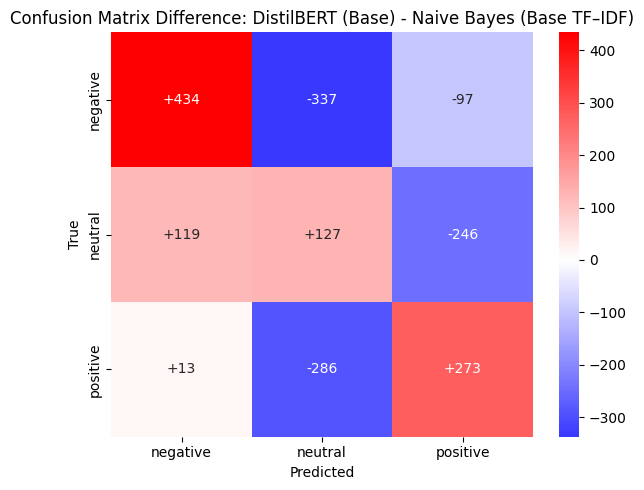

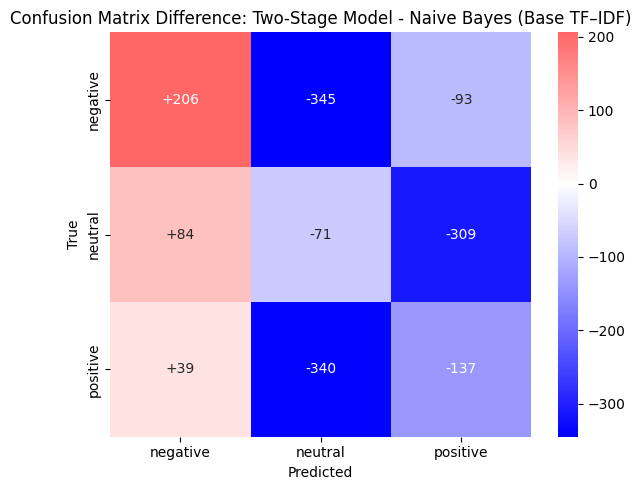

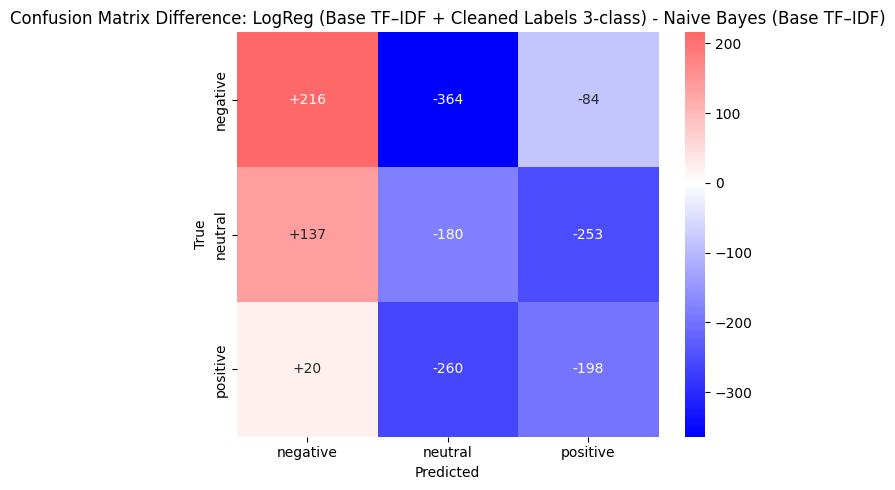

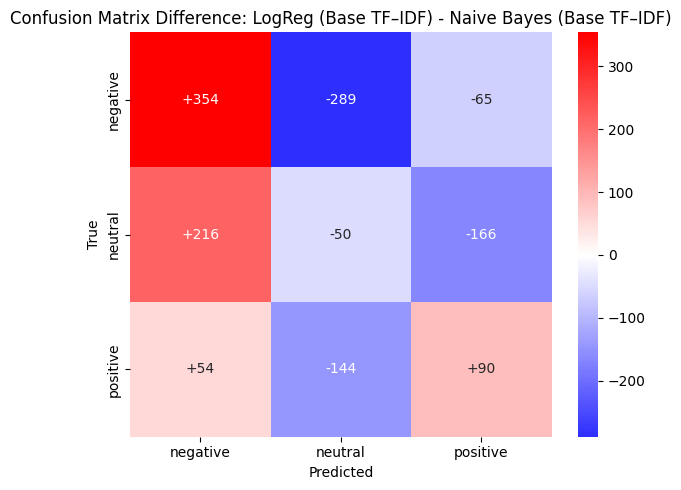

In [ ]:
# Top Models by Macro-F1 score
baseline = "Naive Bayes (Base TF–IDF)"

top_models = (
    results_df
    .sort_values(by="F1_macro", ascending=False)
)

top_model_names = (
    top_models.loc[top_models["Model"] != baseline, "Model"]
    .drop_duplicates()
    .head(4)
    .tolist()
)

# Plot CM diffs against baseline for the top 4(3) models
for name in top_model_names:
    plots.plot_cm_diff(confusion_matrices, baseline, name)


#### Matthews Coefficent 

We compare models using Matthews Correlation Coefficient (MCC) because it captures overall classification quality while remaining robust to class imbalance. MCC incorporates all elements of the confusion matrix and penalizes models that rely on majority-class predictions, making it especially appropriate for our three-class sentiment setting where neutral dominates and negative is underrepresented.

In [ ]:
from sklearn.metrics import matthews_corrcoef, balanced_accuracy_score

model_to_preds = {
    "Naive Bayes (Base TF–IDF)": ("y_test", "y_pred_nb"),
    "LogReg (Base TF–IDF)": ("y_test", "y_pred_log_base"),
    "Two-Stage Model": ("y_test_c3", "y_pred_two"),
    "LogReg (Tuned TF–IDF + Cleaned Labels 3-class)": ("y_test_c3", "y_pred_clean3"),
    "DistilBERT (Base)": ("y_true", "y_pred")
} 

rows = []

for model_name, (y_true_var, y_pred_var) in model_to_preds.items():
    if y_true_var not in globals() or y_pred_var not in globals():
        print(f"Skipping {model_name}: {y_true_var} or {y_pred_var} not in globals()")
        continue

    y_true = globals()[y_true_var]
    y_pred = globals()[y_pred_var]

    mcc = matthews_corrcoef(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    rows.append({
        "Model": model_name,
        "MCC": mcc,
        "Balanced_Accuracy": bal_acc
    })

adv_metrics_df = pd.DataFrame(rows)
display(adv_metrics_df.sort_values("MCC", ascending=False))


,Model,MCC,Balanced_Accuracy
2,Two-Stage Model,0.731923,0.788029
4,DistilBERT (Base),0.646631,0.756306
3,LogReg (Tuned TF–IDF + Cleaned Labels 3-class),0.646631,0.756306
1,LogReg (Base TF–IDF),0.576917,0.715464
0,Naive Bayes (Base TF–IDF),0.387378,0.508355


Two-Stage Model has the highest MCC of all models. MCC evaluates all four confusion-matrix quadrants and is strict analysis, a higher MCC means the two-stage model is likely the most balanced and least biased sentiment model*

## Discussion 


> NOTE: snapshots of metrics for all models tested included here for the discussion of contextual metadata evaluation 

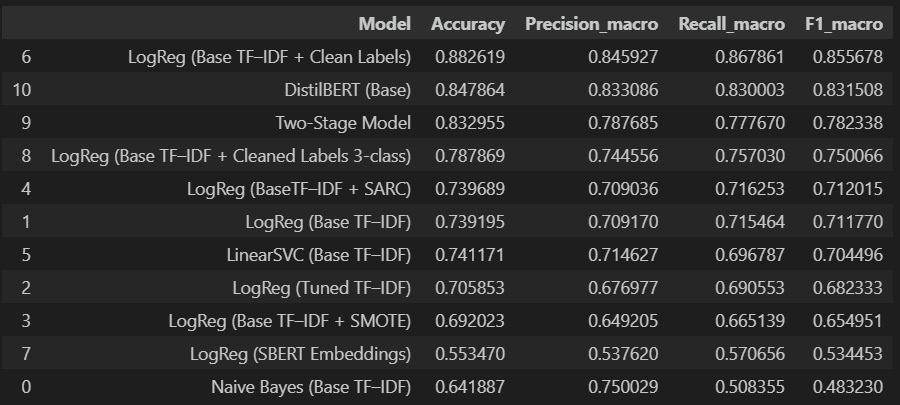

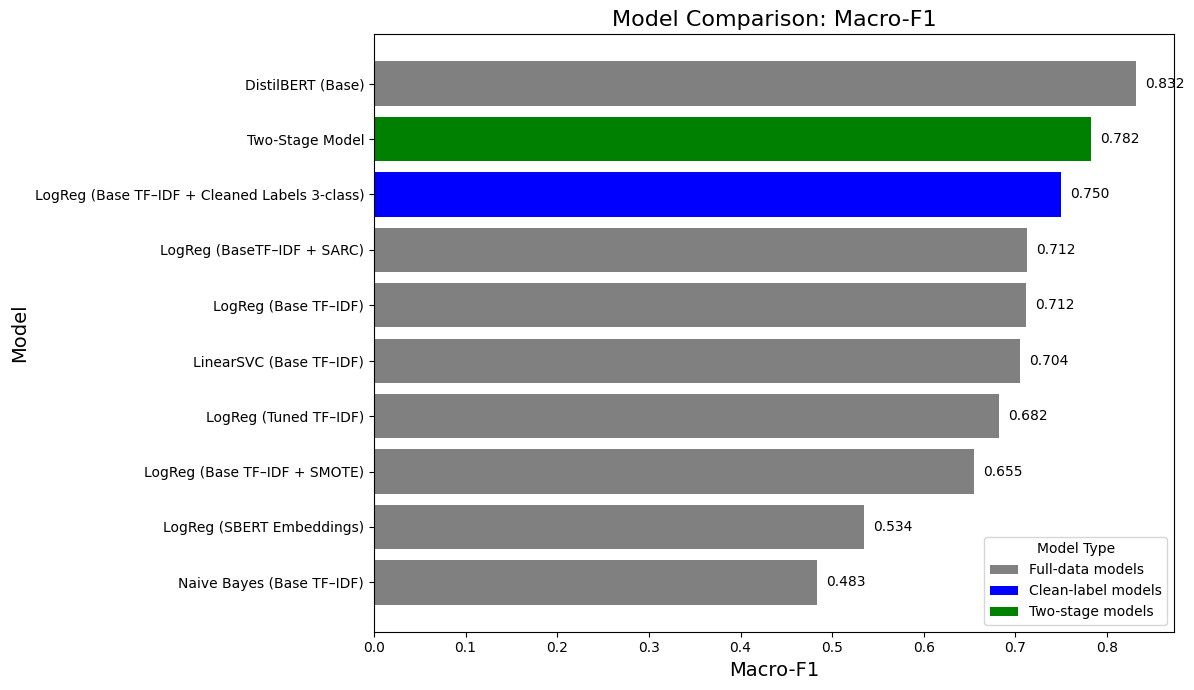

In [ ]:
from IPython.display import Image, display

display(Image(filename="../src/graph_1.JPG"))
display(Image(filename="../src/graph_2.png"))

### Hypothesis Couplets:

> H1: Textual features alone (e.g., word usage, n-grams, embeddings) are sufficient to classify post sentiment at rates significantly better than random chance.

> H0: Textual features alone do not meaningfully improve sentiment classification beyond chance.


Because our top-performing models, DistilBERT, the two-stage classifier, and logistic regression with cleaned labels: all rely primarily on textual representations (TF–IDF features or learned embeddings), we reject the null hypothesis and conclude that textual features alone are sufficient to classify post sentiment at rates well above chance. Despite differences in model complexity, each of these approaches achieved strong performance, indicating that sentiment-relevant signal is largely contained within the text itself.

We therefore accept H1 and reject its corresponding null hypothesis.

> H2: Incorporating contextual metadata (e.g., community identifiers, timestamps, sarcasm indicators) improves sentiment classification accuracy compared to text-only models.

> H0: Metadata does not significantly improve sentiment classification accuracy beyond text-only models.

In contrast, models augmented with additional contextual features such as sarcasm indicators or SMOTE-based resampling showed only marginal or inconsistent improvements, if any. These gains were not substantial enough to meaningfully alter model rankings or error patterns. As a result, we reject H2, concluding that incorporating contextual metadata does not significantly improve sentiment classification performance beyond text-only models in our setting.



### Sentiment Trends Across Platform and Time: 

We did not find conclusive evidence that sentiment is drifting steadily toward a more polarized or more negative direction over time. Instead, the exploratory analysis showed wave-like fluctuations—periods of increased negativity followed by rebounds toward positivity. These oscillations may reflect event-driven dynamics, community turnover, or platform-specific cycles rather than a singular long-term trend. More refined temporal modeling would be required to establish stronger claims about directional sentiment change.

### Identifying Controversy as Associated with Sentiment Shifts 

also found no strong or consistent evidence that specific identity groups or controversial topics reliably elicit more negative or positive sentiment. While certain discussions hinted at weak directional patterns, the signals were sparse and inconsistent across platforms. Given the dataset’s noise and topic diversity, and the lack of diversity in metrics used to evaluate it, the evidence was insufficient to draw robust conclusions about group-level or topic-level emotional patterns.

### Concluding Statements 

Initial experiments explored several feature-engineering and data-balancing strategies, including the addition of sarcasm indicators and the application of SMOTE to address class imbalance. While these modifications occasionally produced small gains in isolated metrics, they did not lead to consistent or statistically meaningful improvements across models. In several cases, SMOTE introduced additional noise that degraded performance on minority sentiment classes, and sarcasm features failed to generalize reliably across topics. These results suggested that model limitations were driven less by feature sparsity or class imbalance and more by ambiguity in the underlying labels themselves.

Although label cleaning improved traditional models dramatically, it came with the drawback of discarding large portions of data, reducing diversity and potentially oversimplifying the real-world problem. The two-stage model provided a solution to this trade-off:
- It replicated many of the benefits of label cleaning
- It preserved the full dataset
- It consistently outperformed all single-stage classical models
- It achieved the highest MCC of any non-transformer model

This indicates that the two-stage approach handled neutrality more responsibly, avoided collapsing classes, and balanced errors across sentiment types more effectively.

Finally, while DistilBERT was the top-performing model in terms of overall accuracy and macro-F1, it still showed the same structural limitations imposed by label quality. The two-stage logistic regression model even surpassed DistilBERT in MCC, demonstrating that even a transformer can have difficulty fully compensating for ambiguous or inconsistent labels. Conversely, our two-stage simple TF–IDF logistic regression system could rival or exceed far more complex architectures when paired with a thoughtful pipeline design.